In [ ]:
!pip install xlrd openpyxl joblib tensorflow scikit-learn -q

In [ ]:
import pandas as pd
import numpy as np
import math
import joblib

from google.colab import files
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
print("File yang digunakan:", file_name)

Saving 10th batutegi_edit_fix.xls to 10th batutegi_edit_fix.xls
File yang digunakan: 10th batutegi_edit_fix.xls


In [ ]:
# baca file xls
df = pd.read_excel(file_name, engine="xlrd")

# rapikan nama kolom
df.columns = [str(c).strip().lower() for c in df.columns]

print("Kolom dataset:")
print(df.columns.tolist())

print(df.head())

Kolom dataset:
['tanggal', 'pos_hujan1', 'pos_hujan2', 'pos_hujan_1', 'pos_hujan_2', 'inflow']
     tanggal pos_hujan1 pos_hujan2 pos_hujan_1  pos_hujan_2     inflow
0 2015-01-01    PH.R067      R.284           7         10.0  19.580614
1 2015-01-02    PH.R067      R.284         3.5          0.0  22.870848
2 2015-01-03    PH.R067      R.284         3.8          0.0  32.056584
3 2015-01-04    PH.R067      R.284          20         28.0  24.472548
4 2015-01-05    PH.R067      R.284         5.4          2.0  23.734439


In [ ]:
df["tanggal"] = pd.to_datetime(df["tanggal"], errors="coerce")

# bersihkan rainfall
rain_cols = ["pos_hujan_1", "pos_hujan_2"]

for col in rain_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace("o", "0", regex=False)
        .str.replace("O", "0", regex=False)
        .str.replace("-", "0", regex=False)
        .str.replace(",", ".", regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

# hapus data kosong
df = df.dropna(subset=["tanggal"] + rain_cols).reset_index(drop=True)

# urutkan tanggal
df = df.sort_values("tanggal").reset_index(drop=True)

print(df.head())

     tanggal pos_hujan1 pos_hujan2  pos_hujan_1  pos_hujan_2     inflow
0 2015-01-01    PH.R067      R.284          7.0         10.0  19.580614
1 2015-01-02    PH.R067      R.284          3.5          0.0  22.870848
2 2015-01-03    PH.R067      R.284          3.8          0.0  32.056584
3 2015-01-04    PH.R067      R.284         20.0         28.0  24.472548
4 2015-01-05    PH.R067      R.284          5.4          2.0  23.734439


In [ ]:
for col in rain_cols:
    for lag in range(1, 8):
        df[f"{col}_lag_{lag}"] = df[col].shift(lag)

# fitur waktu
df["bulan"] = df["tanggal"].dt.month
df["time_index"] = np.arange(1, len(df) + 1)

print(df.head(10))

     tanggal pos_hujan1 pos_hujan2  pos_hujan_1  pos_hujan_2     inflow  \
0 2015-01-01    PH.R067      R.284          7.0         10.0  19.580614   
1 2015-01-02    PH.R067      R.284          3.5          0.0  22.870848   
2 2015-01-03    PH.R067      R.284          3.8          0.0  32.056584   
3 2015-01-04    PH.R067      R.284         20.0         28.0  24.472548   
4 2015-01-05    PH.R067      R.284          5.4          2.0  23.734439   
5 2015-01-06    PH.R067      R.284         11.0         13.0  15.911168   
6 2015-01-07    PH.R067      R.284          0.0          0.0  16.015170   
7 2015-01-08    PH.R067      R.284         26.3          7.0  23.068314   
8 2015-01-09    PH.R067      R.284          0.0          0.0  17.058125   
9 2015-01-10    PH.R067      R.284          0.0          0.0  17.876184   

   pos_hujan_1_lag_1  pos_hujan_1_lag_2  pos_hujan_1_lag_3  pos_hujan_1_lag_4  \
0                NaN                NaN                NaN                NaN   
1           

In [ ]:
#target LSTM
df["target"] = df["pos_hujan_1"].shift(-1)

# hapus baris kosong akibat lag dan target
df = df.dropna().reset_index(drop=True)

print("Jumlah data siap LSTM:", len(df))
print(df.head())

Jumlah data siap LSTM: 4009
     tanggal pos_hujan1 pos_hujan2  pos_hujan_1  pos_hujan_2     inflow  \
0 2015-01-08    PH.R067      R.284         26.3          7.0  23.068314   
1 2015-01-09    PH.R067      R.284          0.0          0.0  17.058125   
2 2015-01-10    PH.R067      R.284          0.0          0.0  17.876184   
3 2015-01-11    PH.R067      R.284          0.0          0.0  23.839671   
4 2015-01-12    PH.R067      R.284          0.0          0.0  18.399551   

   pos_hujan_1_lag_1  pos_hujan_1_lag_2  pos_hujan_1_lag_3  pos_hujan_1_lag_4  \
0                0.0               11.0                5.4               20.0   
1               26.3                0.0               11.0                5.4   
2                0.0               26.3                0.0               11.0   
3                0.0                0.0               26.3                0.0   
4                0.0                0.0                0.0               26.3   

   ...  pos_hujan_2_lag_1  pos_huj

In [ ]:
#simpan lstm dg lag
df.to_excel("dataset_lstm_batutegi_ready.xlsx", index=False)
files.download("dataset_lstm_batutegi_ready.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#pilih fitur input
feature_cols = [
    "pos_hujan_1", "pos_hujan_2",
    "pos_hujan_1_lag_1", "pos_hujan_1_lag_2", "pos_hujan_1_lag_3",
    "pos_hujan_1_lag_4", "pos_hujan_1_lag_5", "pos_hujan_1_lag_6", "pos_hujan_1_lag_7",
    "pos_hujan_2_lag_1", "pos_hujan_2_lag_2", "pos_hujan_2_lag_3",
    "pos_hujan_2_lag_4", "pos_hujan_2_lag_5", "pos_hujan_2_lag_6", "pos_hujan_2_lag_7",
    "bulan", "time_index"
]

target_col = "target"

X = df[feature_cols].values
y = df[target_col].values.reshape(-1, 1)

In [ ]:
#Normalisasi Split 80:20
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

train_size = int(len(X_scaled) * 0.8)

X_train = X_scaled[:train_size]
X_test = X_scaled[train_size:]

y_train = y_scaled[:train_size]
y_test = y_scaled[train_size:]

# reshape untuk LSTM
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3207, 1, 18)
X_test : (802, 1, 18)
y_train: (3207, 1)
y_test : (802, 1)


In [ ]:
#Model LSTM dg adam
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(50),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 50)          │        13,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,051 (133.01 KB)

 Trainable params: 34,051 (133.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#training model
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0090 - val_loss: 0.0102
Epoch 2/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0086 - val_loss: 0.0101
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0087 - val_loss: 0.0101
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0086 - val_loss: 0.0101
Epoch 5/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0086 - val_loss: 0.0102
Epoch 6/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0085 - val_loss: 0.0102
Epoch 7/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0086 - val_loss: 0.0102
Epoch 8/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0085 - val_loss: 0.0102
Epoch 9/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0085 - val_loss: 0.0101
Epoch 10/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0085 - val_loss: 0.0102
Epoch 11/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0086 - val_loss: 0.0102
Epoch 12/100
101/101 ━━━━━━━━━━━━━━━━━━━

In [ ]:
#Prediksi dan evaluasi
y_pred_scaled = model.predict(X_test)

y_test_actual = scaler_y.inverse_transform(y_test)
y_pred_actual = scaler_y.inverse_transform(y_pred_scaled)

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = math.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

mask = y_test_actual.flatten() != 0
if np.sum(mask) > 0:
    mape = mean_absolute_percentage_error(
        y_test_actual[mask],
        y_pred_actual[mask]
    ) * 100
else:
    mape = np.nan

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
MAE : 7.452615450287558
RMSE: 14.528432218682825
MAPE: 102.2347090534579


In [ ]:
#simpan model dan scaler
model.save("model_lstm_batutegi.keras")

joblib.dump(scaler_X, "scaler_X.pkl")
joblib.dump(scaler_y, "scaler_y.pkl")

print("Model dan scaler berhasil disimpan.")

Model dan scaler berhasil disimpan.


In [ ]:
#Simpan hasil Prediksi
hasil = pd.DataFrame({
    "aktual": y_test_actual.flatten(),
    "prediksi": y_pred_actual.flatten(),
    "error": y_test_actual.flatten() - y_pred_actual.flatten()
})

hasil.to_excel("hasil_prediksi_lstm.xlsx", index=False)

metrics_df = pd.DataFrame({
    "metric": ["MAE", "RMSE", "MAPE"],
    "value": [mae, rmse, mape]
})

metrics_df.to_excel("metrics_lstm.xlsx", index=False)

files.download("model_lstm_batutegi.keras")
files.download("scaler_X.pkl")
files.download("scaler_y.pkl")
files.download("hasil_prediksi_lstm.xlsx")
files.download("metrics_lstm.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#hasil grafik loss dan prediksi
hasil = pd.DataFrame({
    "aktual": y_test_actual.flatten(),
    "prediksi": y_pred_actual.flatten(),
    "error": y_test_actual.flatten() - y_pred_actual.flatten()
})

hasil.to_excel("hasil_prediksi_lstm.xlsx", index=False)

metrics_df = pd.DataFrame({
    "metric": ["MAE", "RMSE", "MAPE"],
    "value": [mae, rmse, mape]
})

metrics_df.to_excel("metrics_lstm.xlsx", index=False)

files.download("model_lstm_batutegi.keras")
files.download("scaler_X.pkl")
files.download("scaler_y.pkl")
files.download("hasil_prediksi_lstm.xlsx")
files.download("metrics_lstm.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt

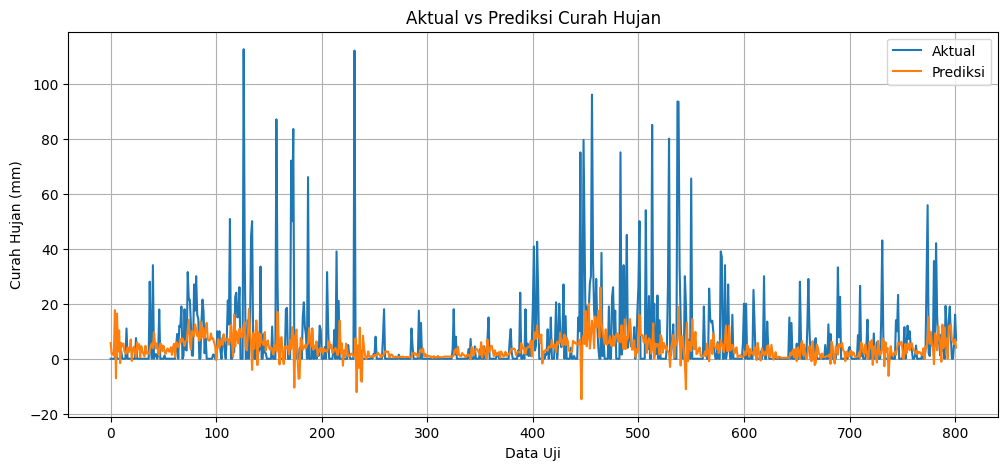

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label="Aktual")
plt.plot(y_pred_actual, label="Prediksi")
plt.title("Aktual vs Prediksi Curah Hujan")
plt.xlabel("Data Uji")
plt.ylabel("Curah Hujan (mm)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

def prediksi_15_hari(df, model, scaler_X, scaler_y):
    df_pred = df.copy()
    hasil_prediksi = []

    feature_cols = [
       "pos_hujan_1", "pos_hujan_2",
    "pos_hujan_1_lag_1", "pos_hujan_1_lag_2", "pos_hujan_1_lag_3",
    "pos_hujan_1_lag_4", "pos_hujan_1_lag_5", "pos_hujan_1_lag_6", "pos_hujan_1_lag_7",
    "pos_hujan_2_lag_1", "pos_hujan_2_lag_2", "pos_hujan_2_lag_3",
    "pos_hujan_2_lag_4", "pos_hujan_2_lag_5", "pos_hujan_2_lag_6", "pos_hujan_2_lag_7",
    "bulan", "time_index"
    ]

    last_date = pd.to_datetime(df_pred["tanggal"].iloc[-1])

    for i in range(1, 16):
        last_row = df_pred.iloc[-1].copy()

        X_input = last_row[feature_cols].values.reshape(1, -1)
        X_scaled = scaler_X.transform(X_input)
        X_scaled = X_scaled.reshape((1, 1, X_scaled.shape[1]))

        pred_scaled = model.predict(X_scaled, verbose=0)
        pred = scaler_y.inverse_transform(pred_scaled)[0][0]

        # curah hujan tidak boleh negatif
        pred = max(pred, 0)

        next_date = last_date + pd.Timedelta(days=i)

        hasil_prediksi.append({
            "tanggal": next_date,
            "hari_ke": f"H+{i}",
            "prediksi_hujan_lstm": pred
        })

        # buat baris baru untuk prediksi berikutnya
        new_row = last_row.copy()
        new_row["tanggal"] = next_date
        new_row["pos_hujan_1"] = pred
        new_row["[pos_hujan_2"] = last_row["pos_hujan_2"]
        new_row["bulan"] = next_date.month
        new_row["time_index"] = last_row["time_index"] + 1

        # update lag rainfall_1
        for lag in range(7, 1, -1):
            new_row[f"pos_hujan_1_lag_{lag}"] = last_row[f"pos_hujan_1_lag_{lag-1}"]
        new_row["pos_hujan_1_lag_1"] = pred

        # update lag rainfall_2 tetap dari data terakhir
        for lag in range(7, 1, -1):
            new_row[f"pos_hujan_2_lag_{lag}"] = last_row[f"pos_hujan_2_lag_{lag-1}"]
        new_row["pos_hujan_2_lag_1"] = last_row["pos_hujan_2"]

        df_pred = pd.concat([df_pred, pd.DataFrame([new_row])], ignore_index=True)

    hasil_15hari = pd.DataFrame(hasil_prediksi)
    return hasil_15hari

In [ ]:
hasil_15hari = prediksi_15_hari(df, model, scaler_X, scaler_y)

print(hasil_15hari)

hasil_15hari.to_excel("prediksi_hujan_15_hari.xlsx", index=False)

      tanggal hari_ke  prediksi_hujan_lstm
0  2025-12-31     H+1             4.045928
1  2026-01-01     H+2             3.730628
2  2026-01-02     H+3             8.189198
3  2026-01-03     H+4             5.951802
4  2026-01-04     H+5             4.312260
5  2026-01-05     H+6             6.138398
6  2026-01-06     H+7             6.378194
7  2026-01-07     H+8             6.572433
8  2026-01-08     H+9             6.848541
9  2026-01-09    H+10             6.853560
10 2026-01-10    H+11             6.947531
11 2026-01-11    H+12             7.028181
12 2026-01-12    H+13             7.104053
13 2026-01-13    H+14             7.159644
14 2026-01-14    H+15             7.190567


In [ ]:
hasil_15hari.to_excel(
    "prediksi_hujan_15_hari.xlsx",
    index=False
)

print("File prediksi 15 hari berhasil dibuat")

File prediksi 15 hari berhasil dibuat


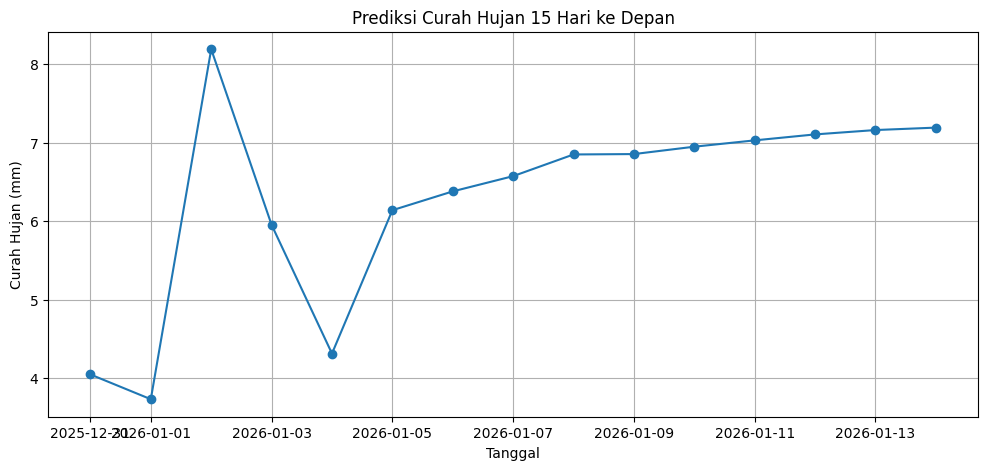

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    hasil_15hari["tanggal"],
    hasil_15hari["prediksi_hujan_lstm"],
    marker="o"
)

plt.title("Prediksi Curah Hujan 15 Hari ke Depan")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid()

plt.show()